# MIS5308 Week 5 PBL – SkyQuest Airways multi-stage sentiment analysis
Notebook version of `week5_analysis.py`. Figures are shown inline and saved to `figures/`; tables go to `results/`.

Stages: (1) aspect-level summary of the provided labels, (2) model comparison against the reference scores, (3) clause-level multi-aspect extraction.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from scipy.stats import pearsonr, spearmanr
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

HERE = Path.cwd()
FIG, RES = HERE / "figures", HERE / "results"
FIG.mkdir(exist_ok=True); RES.mkdir(exist_ok=True)

INK, MUTED, GRID, PANEL = "#1f1f1e", "#6b6a64", "#d9d8d2", "#f4f3ef"
PLAT_COL = {"Twitter": "#2a78d6", "Facebook": "#eb6834", "TripAdvisor": "#1baf7a"}
NEG, POS, MID = "#c2410c", "#1d4ed8", "#f2f1ec"  # diverging poles + neutral midpoint
DIV = LinearSegmentedColormap.from_list("div", ["#9a3412", "#ea8a5b", MID, "#7aa7ec", "#1e40af"])
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10, "axes.edgecolor": GRID,
                     "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED})
%matplotlib inline

## 1. load & merge

In [2]:
xl = pd.read_excel(HERE / "Week5_Dataset.xlsx", sheet_name=None)
df = (xl["Social_Media_Posts"].merge(xl["Cleaned_Text"], on="post_id")
      .merge(xl["Aspect_Assignment"], on="post_id").merge(xl["Sentiment_Scores"], on="post_id"))
df["date"] = pd.to_datetime(df["date"])
AUS = {"Sydney", "Melbourne", "Perth", "Brisbane", "Adelaide", "Canberra", "Hobart", "Darwin"}
df["market"] = np.where(df.user_location.isin(AUS), "Domestic (AU)", "International")
# harmonise the two luggage labels into one aspect (taxonomy lists them together)
df["aspect_h"] = df.aspect.replace({"Luggage": "Baggage & Luggage", "Baggage Handling": "Baggage & Luggage"})
taxonomy = xl["Keyword_Taxonomy"]

## 2. data-quality & taxonomy coverage

In [3]:
tax = {r.category: [k.strip() for k in r.keywords.split(",")] for r in taxonomy.itertuples()}
def tax_hits(text):
    t = text.lower()
    return [c for c, kws in tax.items() if any(k in t for k in kws)]
df["taxonomy_hits"] = df.text.apply(tax_hits)
coverage = (df.taxonomy_hits.str.len() > 0).mean()
quality = pd.Series({
    "posts": len(df), "platforms": df.platform.nunique(), "days": df.date.nunique(),
    "bot_flagged": int(df.is_bot.sum()), "non_english": int((df.language != "en").sum()),
    "duplicates_clean_text": int(df.clean_text.duplicated().sum()),
    "taxonomy_coverage": round(coverage, 2),
    "posts_missed_by_taxonomy": ", ".join(df.loc[df.taxonomy_hits.str.len() == 0, "post_id"].astype(str)),
})

## 3. stage 1 - aspect-level summary (provided labels)

In [4]:
aspect = (df.groupby("aspect_h").aspect_sentiment_score.agg(["mean", "count", "min", "max"])
          .sort_values("mean"))
plat_aspect = df.pivot_table(index="aspect_h", columns="platform", values="aspect_sentiment_score",
                             aggfunc="mean").reindex(aspect.index)
daily = df.groupby("date").aspect_sentiment_score.agg(["mean", "count"])
market = df.groupby("market").aspect_sentiment_score.agg(["mean", "count"])
platform = df.groupby("platform").aspect_sentiment_score.agg(["mean", "count"])
overall = df.overall_sentiment.value_counts()
net_sentiment = df.aspect_sentiment_score.mean()

## 4. stage 2 - model comparison (lexicon baselines)

In [5]:
vader = SentimentIntensityAnalyzer()
df["vader_raw"] = df.text.apply(lambda t: vader.polarity_scores(t)["compound"])
# domain adaptation: airline-disruption terms that generic lexicons treat as neutral
DOMAIN = {"cancelled": -2.0, "canceled": -2.0, "rescheduled": -1.2, "delayed": -1.5, "delays": -1.5,
          "crashing": -2.0, "lost": -1.8, "waiting": -1.0, "confusing": -1.6, "chaos": -1.5,
          "warning": -0.5,
          # "support" is a noun here (help desk), and "not responding" should flip negative
          "support": 0.0, "responding": 1.2}
vader_d = SentimentIntensityAnalyzer(); vader_d.lexicon.update(DOMAIN)
df["vader_domain"] = df.text.apply(lambda t: vader_d.polarity_scores(t)["compound"])

def label(x, lo=-0.05, hi=0.05):
    return "Negative" if x < lo else "Positive" if x > hi else "Neutral/Mixed"
ref = df.overall_sentiment.replace({"Mixed": "Neutral/Mixed"})
model_eval = pd.DataFrame({
    m: {"pearson_r": pearsonr(df[m], df.aspect_sentiment_score)[0],
        "spearman_rho": spearmanr(df[m], df.aspect_sentiment_score)[0],
        "label_agreement": (df[m].apply(label) == ref).mean(),
        "mean_abs_error": (df[m] - df.aspect_sentiment_score).abs().mean()}
    for m in ["vader_raw", "vader_domain"]}).T.round(2)

## 5. stage 3 - multi-aspect extraction (clause level)

In [6]:
ASPECTS = [  # (aspect, regex) - checked per clause, several aspects may fire per post
    ("Cancellations & Delays", r"cancel|reschedul|delays\b|waiting \d+ hours|unexpected delay"),
    ("Communication", r"no email|no warning|without warning|not told|nobody told|communication|updates"),
    ("Customer Support", r"support"),
    ("Refund Process", r"refund"),
    ("Website / Digital", r"website"),
    ("Baggage & Luggage", r"baggage|luggage|bag\b"),
    ("Crew & Staff", r"crew|staff|pilot"),
]
def clauses(text):
    return [c.strip() for c in re.split(r"[.!?;]|\bbut\b|\bthough\b|\bdespite\b", text) if c.strip()]
rows = []
for r in df.itertuples():
    for c in clauses(r.text):
        s = vader_d.polarity_scores(c)["compound"]
        for a, pat in ASPECTS:
            if re.search(pat, c, re.I):
                rows.append({"post_id": r.post_id, "platform": r.platform, "date": r.date,
                             "market": r.market, "aspect": a, "clause": c, "score": s})
multi = pd.DataFrame(rows)
multi_aspect = multi.groupby("aspect").score.agg(["mean", "count"]).sort_values("mean")
single_n = df.aspect_h.value_counts()

## Save tables

In [7]:
df.drop(columns=["taxonomy_hits"]).to_csv(RES / "posts_merged.csv", index=False)
quality.to_csv(RES / "data_quality.csv", header=["value"])
aspect.round(3).to_csv(RES / "aspect_summary.csv")
plat_aspect.round(3).to_csv(RES / "platform_by_aspect.csv")
daily.round(3).to_csv(RES / "daily_sentiment.csv")
market.round(3).to_csv(RES / "market_sentiment.csv")
model_eval.to_csv(RES / "model_evaluation.csv")
multi.assign(score=multi.score.round(3)).to_csv(RES / "multi_aspect_clauses.csv", index=False)
multi_aspect.round(3).to_csv(RES / "multi_aspect_summary.csv")

## Figures

In [8]:
def clean(ax, grid="x"):
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis=grid, color=GRID, lw=.6); ax.set_axisbelow(True)

def aspect_bars(ax, tbl, title):
    cols = [NEG if v < 0 else POS for v in tbl["mean"]]
    ax.barh(tbl.index, tbl["mean"], color=cols, height=.6)
    for y, (v, n) in enumerate(zip(tbl["mean"], tbl["count"])):
        ax.text(v + (-.03 if v < 0 else .03), y, f"{v:+.2f}  (n={n})", va="center",
                ha="right" if v < 0 else "left", fontsize=8, color=INK)
    ax.axvline(0, color=MUTED, lw=.8); ax.set_xlim(-1.35, 1.45)
    ax.set_xlabel("Mean aspect sentiment (-1 to +1)"); clean(ax)
    ax.set_title(title, loc="left", fontsize=11, color=INK)

def heatmap(ax, tbl, title, cbar=True):
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    im = ax.imshow(tbl.values, cmap=DIV, norm=norm, aspect="auto")
    ax.set_xticks(range(tbl.shape[1]), tbl.columns); ax.set_yticks(range(tbl.shape[0]), tbl.index)
    for (i, j), v in np.ndenumerate(tbl.values):
        ax.text(j, i, "–" if np.isnan(v) else f"{v:+.2f}", ha="center", va="center", fontsize=8.5,
                color="white" if not np.isnan(v) and abs(v) > .6 else INK)
    ax.tick_params(length=0); [s.set_visible(False) for s in ax.spines.values()]
    ax.set_title(title, loc="left", fontsize=11, color=INK)
    return im

EVENTS = {"2025-01-02": "Mass cancellations\n(no notice)", "2025-01-04": "Rescheduling &\nbaggage delays",
          "2025-01-06": "First refunds\nreceived"}
def trend(ax, title):
    x = daily.index
    ax.axhline(0, color=MUTED, lw=.8)
    ax.plot(x, daily["mean"], color=INK, lw=2, zorder=2)
    for p, g in df.groupby("platform"):
        ax.scatter(g.date, g.aspect_sentiment_score, s=45, color=PLAT_COL[p], edgecolors="white",
                   linewidths=1.5, zorder=3, label=p)
    ax.scatter(x, daily["mean"], s=60, color=INK, zorder=4, label="Daily mean")
    for d, txt in EVENTS.items():
        d = pd.Timestamp(d); ax.axvline(d, color=GRID, lw=1, ls="--", zorder=1)
        ax.text(d, 1.02, txt, fontsize=7.5, color=MUTED, ha="center", va="bottom")
    ax.set_ylim(-1.1, 1.35); ax.set_xticks(x, [d.strftime("%d %b") for d in x])
    ax.set_ylabel("Aspect sentiment"); clean(ax, "y")
    ax.legend(frameon=False, fontsize=7.5, loc="lower right", ncol=2)
    ax.set_title(title, loc="left", fontsize=11, color=INK)

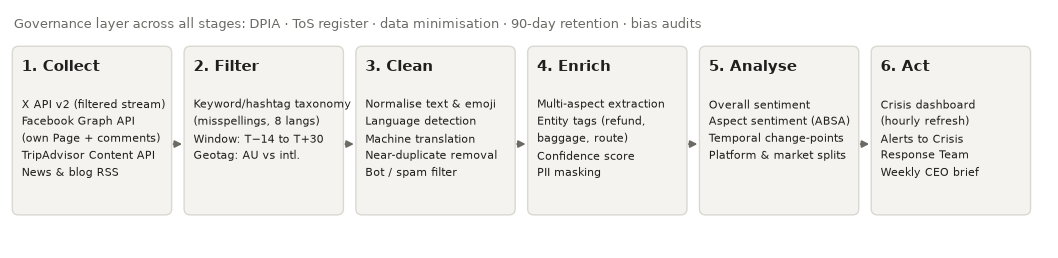

In [9]:
# Fig 1 - pipeline architecture
fig, ax = plt.subplots(figsize=(13.4, 3.1)); ax.axis("off"); ax.set_xlim(0, 13.3); ax.set_ylim(0, 3.1)
stages = [("1. Collect", "X API v2 (filtered stream)\nFacebook Graph API\n(own Page + comments)\nTripAdvisor Content API\nNews & blog RSS"),
          ("2. Filter", "Keyword/hashtag taxonomy\n(misspellings, 8 langs)\nWindow: T−14 to T+30\nGeotag: AU vs intl."),
          ("3. Clean", "Normalise text & emoji\nLanguage detection\nMachine translation\nNear-duplicate removal\nBot / spam filter"),
          ("4. Enrich", "Multi-aspect extraction\nEntity tags (refund,\nbaggage, route)\nConfidence score\nPII masking"),
          ("5. Analyse", "Overall sentiment\nAspect sentiment (ABSA)\nTemporal change-points\nPlatform & market splits"),
          ("6. Act", "Crisis dashboard\n(hourly refresh)\nAlerts to Crisis\nResponse Team\nWeekly CEO brief")]
w, gap = 2.0, .2
for i, (h, body) in enumerate(stages):
    x = .05 + i * (w + gap)
    ax.add_patch(plt.matplotlib.patches.FancyBboxPatch((x, .45), w, 2.15, boxstyle="round,pad=0.02,rounding_size=0.08",
                 fc=PANEL, ec=GRID, lw=1))
    ax.text(x + .1, 2.45, h, fontsize=11, weight="bold", color=INK, va="top")
    ax.text(x + .1, 1.98, body, fontsize=8.2, color=INK, va="top", linespacing=1.5)
    if i < len(stages) - 1:
        ax.annotate("", xy=(x + w + gap - .01, 1.35), xytext=(x + w + .01, 1.35),
                    arrowprops=dict(arrowstyle="-|>", color=MUTED, lw=1.4))
ax.text(.05, 3.0, "Governance layer across all stages: DPIA · ToS register · data minimisation · 90-day retention · bias audits",
        fontsize=9, color=MUTED, va="top")
fig.savefig(FIG / "fig1_pipeline.png", dpi=200, bbox_inches="tight"); plt.show()

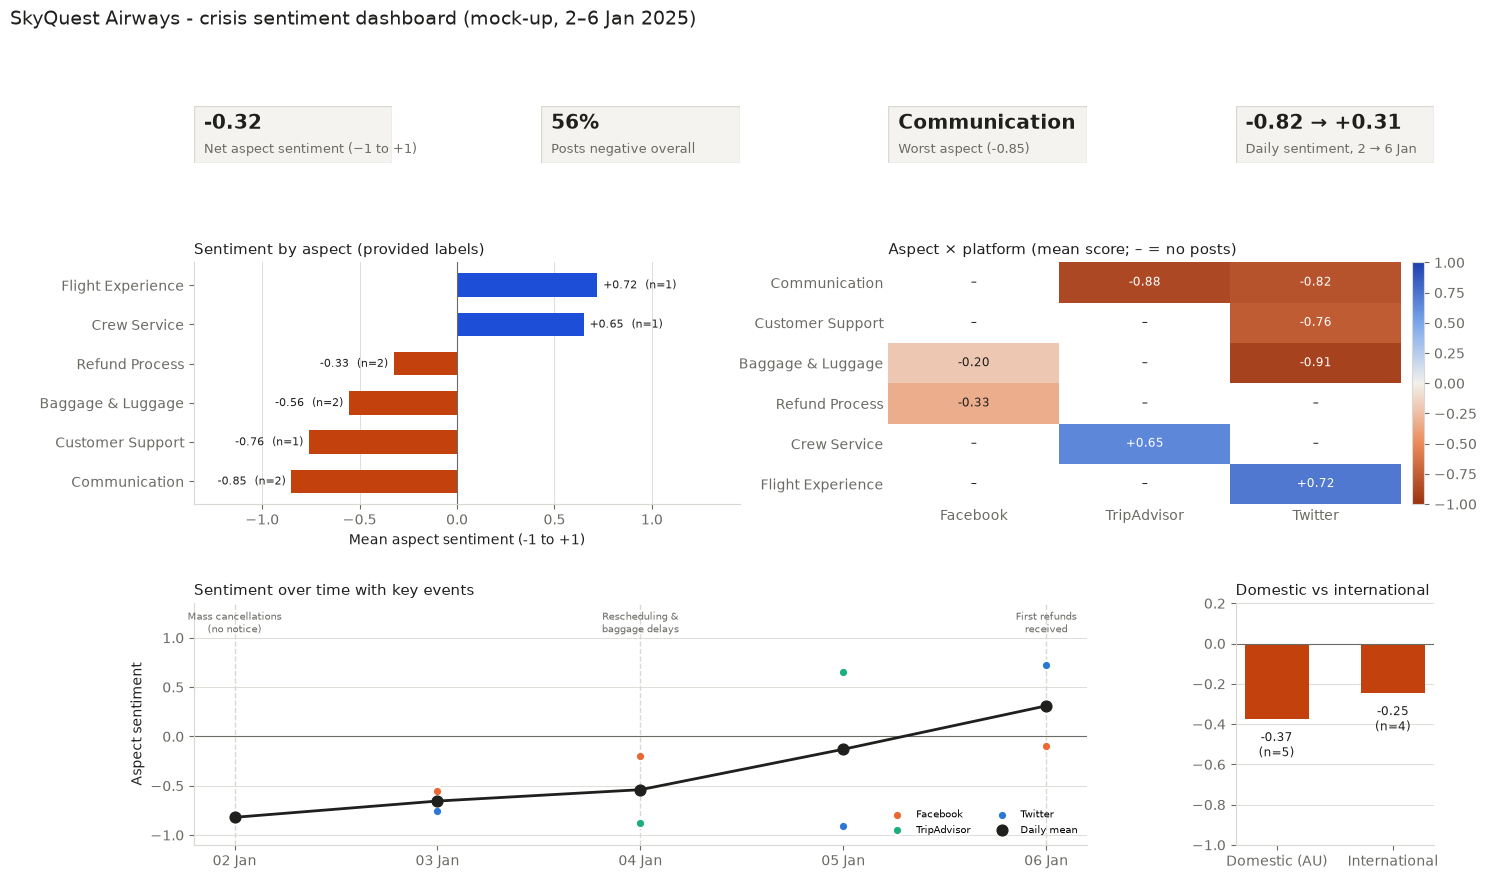

In [10]:
# Fig 2 - dashboard mock-up
fig = plt.figure(figsize=(16, 9.6))
gs = fig.add_gridspec(3, 4, height_ratios=[.5, 2.1, 2.1], hspace=.55, wspace=.75)
neg_share = (df.overall_sentiment == "Negative").mean()
kpis = [(f"{net_sentiment:+.2f}", "Net aspect sentiment (−1 to +1)"),
        (f"{neg_share:.0%}", "Posts negative overall"),
        (f"{aspect['mean'].idxmin()}", f"Worst aspect ({aspect['mean'].min():+.2f})"),
        (f"{daily['mean'].iloc[0]:+.2f} → {daily['mean'].iloc[-1]:+.2f}", "Daily sentiment, 2 → 6 Jan")]
for i, (v, k) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i]); ax.axis("off")
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fc=PANEL, ec=GRID))
    ax.text(.05, .6, v, fontsize=14.5, color=INK, transform=ax.transAxes, weight="bold")
    ax.text(.05, .18, k, fontsize=9, color=MUTED, transform=ax.transAxes)
aspect_bars(fig.add_subplot(gs[1, :2]), aspect, "Sentiment by aspect (provided labels)")
im = heatmap(fig.add_subplot(gs[1, 2:]), plat_aspect, "Aspect × platform (mean score; – = no posts)")
fig.colorbar(im, ax=fig.axes[-1], fraction=.04, pad=.02)
trend(fig.add_subplot(gs[2, :3]), "Sentiment over time with key events")
ax = fig.add_subplot(gs[2, 3])
m = market.reindex(["Domestic (AU)", "International"])
ax.bar(m.index, m["mean"], color=[NEG if v < 0 else POS for v in m["mean"]], width=.55)
for x, (v, n) in enumerate(zip(m["mean"], m["count"])):
    ax.text(x, v - .06, f"{v:+.2f}\n(n={n})", ha="center", va="top", fontsize=8.5, color=INK)
ax.axhline(0, color=MUTED, lw=.8); ax.set_ylim(-1, .2); clean(ax, "y")
ax.set_title("Domestic vs international", loc="left", fontsize=11, color=INK)
fig.suptitle("SkyQuest Airways - crisis sentiment dashboard (mock-up, 2–6 Jan 2025)", x=.01, ha="left",
             fontsize=14, color=INK)
fig.savefig(FIG / "fig2_dashboard_mockup.png", dpi=170, bbox_inches="tight"); plt.show()

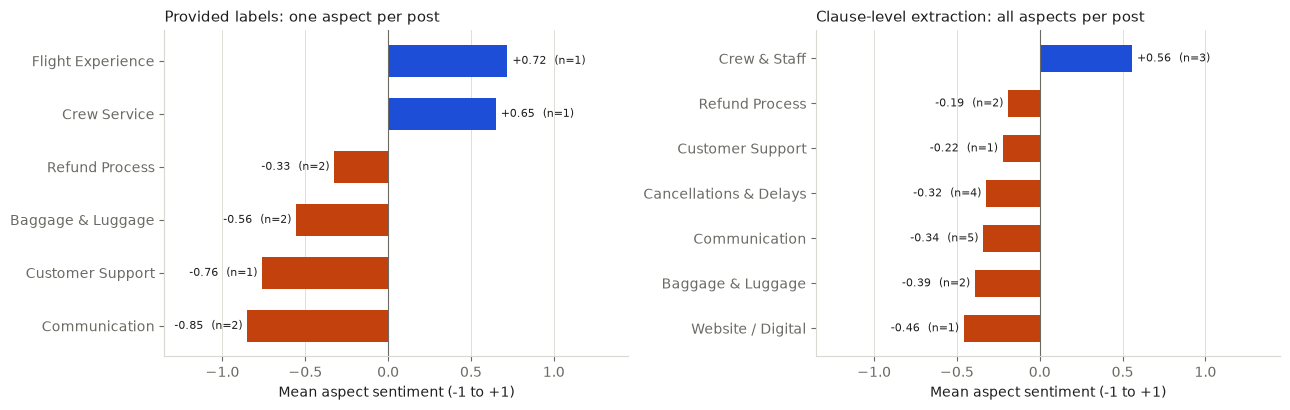

In [11]:
# Fig A1 - provided single-label vs multi-aspect extraction
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True)
aspect_bars(axes[0], aspect, "Provided labels: one aspect per post")
aspect_bars(axes[1], multi_aspect, "Clause-level extraction: all aspects per post")
fig.tight_layout(); fig.savefig(FIG / "figA1_single_vs_multi_aspect.png", dpi=200); plt.show()

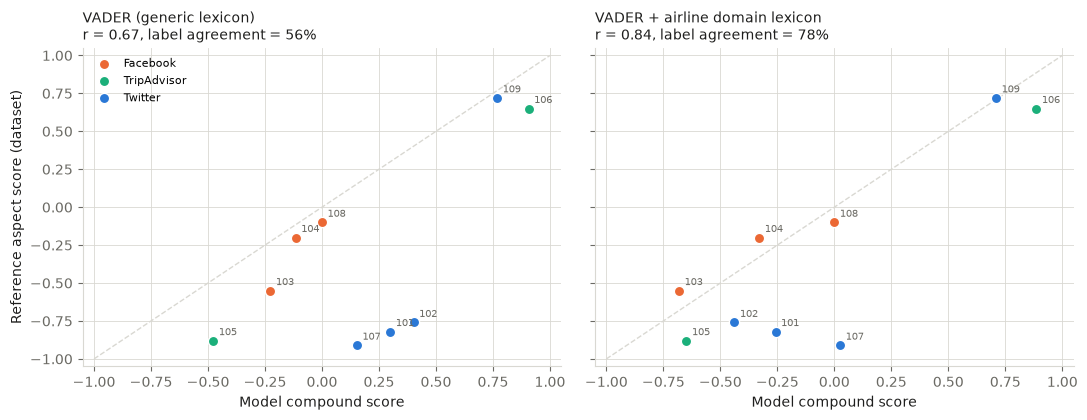

In [12]:
# Fig A2 - model agreement
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, m, t in zip(axes, ["vader_raw", "vader_domain"], ["VADER (generic lexicon)", "VADER + airline domain lexicon"]):
    ax.plot([-1, 1], [-1, 1], color=GRID, lw=1, ls="--")
    for p, g in df.groupby("platform"):
        ax.scatter(g[m], g.aspect_sentiment_score, s=55, color=PLAT_COL[p], edgecolors="white", label=p, zorder=3)
    for r in df.itertuples():
        ax.annotate(str(r.post_id), (getattr(r, m), r.aspect_sentiment_score), xytext=(4, 4),
                    textcoords="offset points", fontsize=7, color=MUTED)
    e = model_eval.loc[m]
    ax.set_title(f"{t}\nr = {e.pearson_r:.2f}, label agreement = {e.label_agreement:.0%}", loc="left", fontsize=10, color=INK)
    ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05); ax.set_xlabel("Model compound score"); clean(ax, "both")
axes[0].set_ylabel("Reference aspect score (dataset)"); axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout(); fig.savefig(FIG / "figA2_model_agreement.png", dpi=200); plt.show()

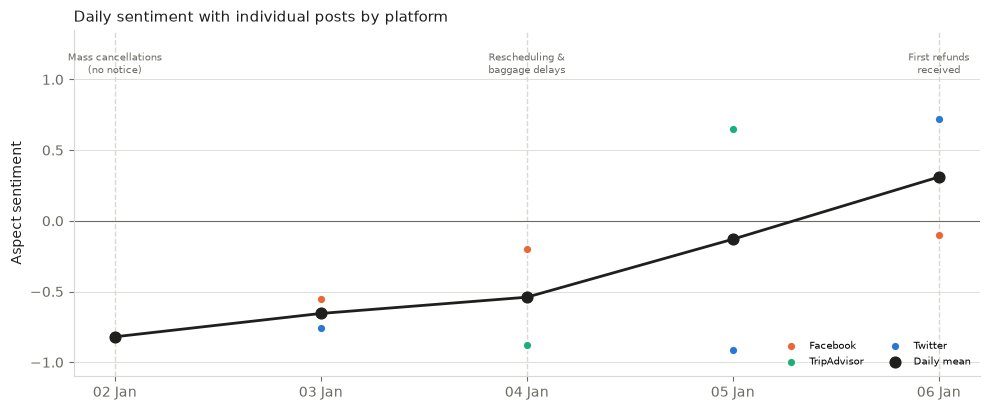

In [13]:
# Fig A3 - larger trend chart
fig, ax = plt.subplots(figsize=(10, 4.2)); trend(ax, "Daily sentiment with individual posts by platform")
fig.tight_layout(); fig.savefig(FIG / "figA3_temporal.png", dpi=200); plt.show()

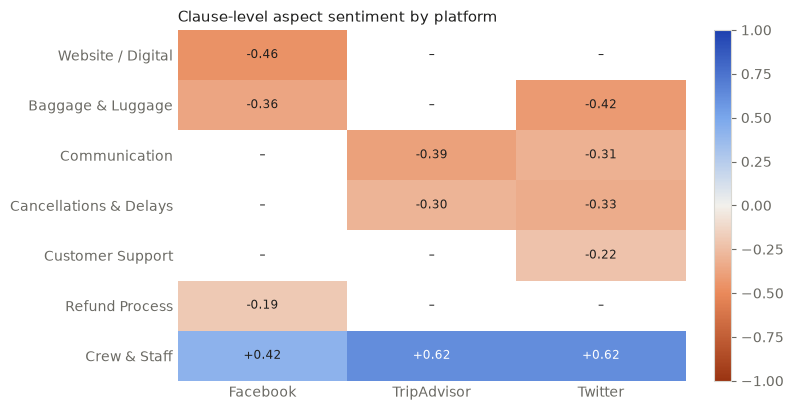

In [14]:
# Fig A4 - platform and market heatmap from multi-aspect clauses
pm = multi.pivot_table(index="aspect", columns="platform", values="score", aggfunc="mean").reindex(multi_aspect.index)
fig, ax = plt.subplots(figsize=(8, 4.2)); im = heatmap(ax, pm, "Clause-level aspect sentiment by platform")
fig.colorbar(im, ax=ax, fraction=.04); fig.tight_layout()
fig.savefig(FIG / "figA4_multi_aspect_platform.png", dpi=200); plt.show()

## Console summary

In [15]:
pd.set_option("display.width", 200)
print(quality, "\n"); print(aspect.round(2), "\n"); print(plat_aspect.round(2), "\n")
print(daily.round(3), "\n"); print(market.round(3), "\n"); print(platform.round(3), "\n"); print(overall, "\n")
print(df[["post_id", "aspect_sentiment_score", "vader_raw", "vader_domain"]].round(2), "\n")
print(model_eval, "\n"); print(multi[["post_id", "aspect", "clause", "score"]].round(2).to_string(), "\n")
print(multi_aspect.round(2))

posts                              9
platforms                          3
days                               5
bot_flagged                        0
non_english                        0
duplicates_clean_text              0
taxonomy_coverage               0.78
posts_missed_by_taxonomy    102, 109
dtype: object 

                   mean  count   min   max
aspect_h                                  
Communication     -0.85      2 -0.88 -0.82
Customer Support  -0.76      1 -0.76 -0.76
Baggage & Luggage -0.56      2 -0.91 -0.20
Refund Process    -0.32      2 -0.55 -0.10
Crew Service       0.65      1  0.65  0.65
Flight Experience  0.72      1  0.72  0.72 

platform           Facebook  TripAdvisor  Twitter
aspect_h                                         
Communication           NaN        -0.88    -0.82
Customer Support        NaN          NaN    -0.76
Baggage & Luggage     -0.20          NaN    -0.91
Refund Process        -0.32          NaN      NaN
Crew Service            NaN         0.65  